In [1]:
# --- 1. CONFIGURAÇÕES GERAIS E AMBIENTE ---
import os
import json
import random
import logging
import warnings
import tempfile
import hashlib
import dagshub
import mlflow
import mlflow.sklearn
import mlflow.pytorch
import joblib

# Silenciando avisos para um log mais limpo
warnings.filterwarnings('ignore')
logging.getLogger("mlflow").setLevel(logging.ERROR)

# --- 2. MANIPULAÇÃO E ANÁLISE DE DADOS ---
import pandas as pd
import numpy as np
import itertools
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# --- 3. MODELAGEM CLASSÍCA (SKLEARN) ---
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, 
    roc_auc_score, precision_recall_curve, auc, 
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- 4. DEEP LEARNING (PYTORCH) ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# --- 5. VISUALIZAÇÃO ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- 6. HELPERS COMPARTILHADOS (single source of truth com src/) ---
import sys
sys.path.insert(0, "..")
from src.application.business_metrics import (
    VALOR_CLIENTE_LTV, CUSTO_RETENCAO,
    find_optimal_threshold, calculate_metrics,
)


In [2]:
# Configuração de Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Estética dos Gráficos
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 10,
    'axes.titlesize': 14
})

# Test Size
TEST_SIZE = 0.2

# Nome do experimento no MLflow
EXPERIMENT_NAME = "Churn-Predict-Telco-Etapa2-Modelagem"

# Path do Dataset
DATASET_PATH = "../data/dataset/telco_customer_churn.csv"

# VALOR_CLIENTE_LTV e CUSTO_RETENCAO importados de src.application.business_metrics

# Dags Hub Variáveis
REPO_OWNER = "JosueJNLui"
REPO_NAME = "fiap-mlet-challenge-fase-1"

In [3]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:

    # Tenure bucket
    bins = [-1, 12, 24, 48, np.inf]
    labels = ['0-12', '13-24', '25-48', '49+']
    df['tenure_bucket'] = pd.cut(df['tenure'], bins=bins, labels=labels)

    # Avg Charges per month
    df['avg_charges_per_month'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

    # Charge vs EXpected
    df['charge_vs_expected'] = df['MonthlyCharges'] - df['avg_charges_per_month']

    # Num services
    service_list = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 
                    'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                    'StreamingTV', 'StreamingMovies', 'InternetService']
    df['num_services'] = df[service_list].sum(axis=1)

    return df

In [4]:
def hot_encoding(df: pd.DataFrame) -> pd.DataFrame:

    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f"Colunas categóricas ({len(categorical_cols)}): {categorical_cols}\n")

    # Mostrar cardinalidade de cada coluna categórica
    for col in categorical_cols:
        print(f"  {col}: {df[col].nunique()} valores únicos → {df[col].unique()}")

    return pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [5]:
def preprocessing(df: pd.DataFrame) -> tuple:

    # Limpeza inicial - Remover coluuna de ID
    df = df.copy()
    df.drop(columns=['customerID'], inplace=True)

    # Converter para binário
    binary_cols = ['Partner', 'Dependents', 'PhoneService'
                   , 'PaperlessBilling', 'OnlineSecurity', 'OnlineBackup'
                   , 'DeviceProtection', 'TechSupport', 'StreamingTV'
                   , 'StreamingMovies', 'MultipleLines'
                   ]
    for col in binary_cols:
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})
    
    # Tratar coluna InternetService
    df['InternetService'] = df['InternetService'].map({'DSL': 1, 'Fiber optic': 1, 'No': 0})

    # Tratar coluna TotalCharges
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    mask = df['TotalCharges'].isna()
    df.loc[mask, 'TotalCharges'] = df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']

    # Aplicar transformação Logarítmica
    df['TotalCharges'] = np.log1p(df['TotalCharges'])

    # Criação das Features
    df = create_features(df)

    # One-Hot Encoding usando get_dummies
    df_encoded = hot_encoding(df)

    return df_encoded

In [6]:
# find_optimal_threshold importado de src.application.business_metrics
# (compartilhado com eda.ipynb e models-comparison.ipynb).
# Implementação: varre 100 thresholds em [0.01, 0.99] e devolve o que maximiza o lucro líquido.


In [7]:
# calculate_metrics importado de src.application.business_metrics
# Assinatura: calculate_metrics(y_true, y_proba, threshold, return_confusion_matrix=False)
# - quando return_confusion_matrix=True, devolve (dict, cm) — usado abaixo na avaliação final.


In [8]:
def run_kfold_analysis(model, X, y, skf):
    """Executa o K-Fold e retorna a lista de métricas de cada dobra."""
    list_metrics = []
    list_thresholds = []
    
    for train_idx, val_idx in skf.split(X, y):
        # Splits do Fold
        X_train_f, X_val_f = X.iloc[train_idx], X.iloc[val_idx]
        y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]
        
        # Pipeline: Fit Scaler -> Transform -> Train
        scaler = StandardScaler()
        X_train_f_scaled = scaler.fit_transform(X_train_f)
        X_val_f_scaled = scaler.transform(X_val_f)
        
        model.fit(X_train_f_scaled, y_train_f)
        
        # Otimização de Threshold por Fold
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_val_f_scaled)[:, 1]
            t_opt = find_optimal_threshold(y_val_f, y_proba)
            y_pred = (y_proba >= t_opt).astype(int)
        else:
            y_proba = np.zeros(len(y_val_f))
            y_pred = model.predict(X_val_f_scaled)
            t_opt = 0.5
        
        m = calculate_metrics(y_val_f, y_proba, t_opt)
        list_metrics.append(m)
        list_thresholds.append(t_opt)
        
    return list_metrics, list_thresholds

In [9]:
def prepare_data_for_kfold(df_encoded: pd.DataFrame, test_size: float, random_state: int, target_col='target'):
    """
    Apenas separa o Teste Final. 
    O escalonamento e o split de validação serão feitos dentro de cada fold.
    """
    X = df_encoded.drop(columns=[target_col])
    y = df_encoded[target_col]

    # 1. Separa 20% para o Teste Final
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    # Retornamos X_temp e y_temp para serem usados no StratifiedKFold
    return X_temp, X_test, y_temp, y_test

In [10]:
def evaluate_and_log(model, model_name, X_tr, y_tr, X_te, y_te, kfold_metrics: list, lucros_kfold:list, list_thresholds: list,
                     mlflow_train_dataset, mlflow_test_dataset, dataset_params: dict, extra_params=None):
    """Treina o modelo, avalia e registra tudo no MLflow."""

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    t_campeao = np.median(list_thresholds)

    with mlflow.start_run(run_name=model_name) as parent_run:
        mlflow.set_tag("etapa", "2")

        # RUN Filha
        with mlflow.start_run(run_name=f"{model_name}_kfold_validation", nested=True):
            # Log das métricas resumidas
            mlflow.log_metrics(kfold_metrics)
            mlflow.log_metrics({
                "kfold_lucro_medio": np.mean(lucros_kfold),
                "kfold_lucro_std":   np.std(lucros_kfold),
                "kfold_lucro_min":   np.min(lucros_kfold),
                "kfold_lucro_max":   np.max(lucros_kfold)
            })
            for i, valor in enumerate(lucros_kfold):
                mlflow.log_metric("lucro_por_fold", valor, step=i)
            mlflow.set_tag("stage", "validation")

            # 1. Converte para tipos nativos do Python
            lucros_nativos = [float(x) for x in lucros_kfold]

            # 2. Cria o arquivo temporário
            with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as tmp:
                json.dump(lucros_nativos, tmp)
                temp_path = tmp.name

            # 3. Faz o log usando o caminho
            mlflow.log_artifact(temp_path, "vetor_lucros.json")

            # Remove o arquivo temporário após o log
            import os
            os.unlink(temp_path)

        # Treinar o modelo e fazer predições
        model.fit(X_tr_scaled, y_tr)
        y_pred = model.predict(X_te_scaled)

        # Probabilidades e Threshold otimizado
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_te_scaled)[:, 1]
            y_pred_final = (y_proba >= t_campeao).astype(int)
        else:
            y_proba = np.zeros(len(y_te))

        # Cálculo das métricas (incluindo as de negócio)
        metrics, cm = calculate_metrics(y_te, y_proba, t_campeao, return_confusion_matrix=True)
        
        # Log DataSet
        mlflow.log_input(mlflow_train_dataset, context="training")
        mlflow.log_input(mlflow_test_dataset, context="testing")

        # Log de parâmetros e métricas
        mlflow.log_params(dataset_params)
        if extra_params:
            mlflow.log_params(extra_params)

        # Log das métricas resumidas
        mlflow.log_metrics(metrics)
        mlflow.set_tag("stage", "test_final")

        # Log do Modelo
        mlflow.set_tag("model_type", model_name)
        model_info = mlflow.sklearn.log_model(
            model,
            name="baseline",
            registered_model_name=model_name,
        )

        scaler_filename = "scaler.joblib"
        joblib.dump(scaler, scaler_filename)
        mlflow.log_artifact(scaler_filename, artifact_path="model_components")
        
        # Limpa o arquivo local temporário
        if os.path.exists(scaler_filename):
            os.remove(scaler_filename)

        # --- Print ---
        print(f"\n{'='*60}")
        print(f" {model_name}")
        print(f"{'='*60}")
        print(classification_report(y_te, y_pred_final, target_names=["Sem churn", "Com churn"]))
        print(f"  ROC-AUC:  {metrics['roc_auc']:.4f}")
        print(f"  PR-AUC:   {metrics['pr_auc']:.4f}")
        print(f"  TP Custo churn evitado: R$ {metrics['custo_churn_evitado_BRL']:,.0f}")
        print(f"  FN Custo churn perdido: R$ {metrics['custo_churn_perdido_BRL']:,.0f}")
        print(f"  FP Custo falso positivo: R$ {metrics['custo_falso_positivo_BRL']:,.0f}")
        print(f"  💰 Lucro Líquido: R$ {metrics['lucro_liquido_BRL']:,.0f}")

    return metrics, cm

In [11]:
# Leitura do dataset
df_raw = pd.read_csv('../data/dataset/telco_customer_churn.csv')
df = df_raw.copy()
df.rename(columns={'Churn': 'target'}, inplace=True)
df['target'] = df['target'].map({'Yes': 1, 'No': 0})

# Pre-processamento e preparação dos dados
df_encoded = preprocessing(df)
X_dev, X_test, y_dev, y_test = prepare_data_for_kfold(df_encoded, test_size=TEST_SIZE, random_state=SEED)

# Configuração do K-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

Colunas categóricas (4): ['gender', 'Contract', 'PaymentMethod', 'tenure_bucket']

  gender: 2 valores únicos → ['Female' 'Male']
  Contract: 3 valores únicos → ['Month-to-month' 'One year' 'Two year']
  PaymentMethod: 4 valores únicos → ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
  tenure_bucket: 4 valores únicos → ['0-12', '25-48', '13-24', '49+']
Categories (4, object): ['0-12' < '13-24' < '25-48' < '49+']


In [12]:
# Configuração de Rastreabilidade atrabés do MLflow + DagsHub
dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)
mlflow.set_experiment(EXPERIMENT_NAME)

Accessing as zonetti

Initialized MLflow to track repo "JosueJNLui/fiap-mlet-challenge-fase-1"

Repository JosueJNLui/fiap-mlet-challenge-fase-1 initialized!

<Experiment: artifact_location='mlflow-artifacts:/ebdb8ff88141471dab777eb757701525', creation_time=1777840206482, experiment_id='13', last_update_time=1777840206482, lifecycle_stage='active', name='Churn-Predict-Telco-Etapa2-Modelagem', tags={}, workspace='default'>

In [13]:
# Calculdo do MD5 do dataset para rastreabilidade

with open(DATASET_PATH, "rb") as f:
    DATASET_VERSION = hashlib.md5(f.read()).hexdigest()

print(f"Dataset MD5: {DATASET_VERSION}")

dataset_params = {
    "dataset_path": DATASET_PATH,
    "dataset_version_md5": DATASET_VERSION,
    "n_train": X_dev.shape[0],
    "n_test": X_test.shape[0],
    "n_features": X_dev.shape[1],
    "target_rate_train": round(y_dev.mean(), 4),
    "test_size": TEST_SIZE,
    "random_state": SEED
}

# Dataset MLflow para rastreabilidade na UI
mlflow_train_dataset = mlflow.data.from_pandas(
    X_dev.assign(Churn=y_dev),
    source=DATASET_PATH,
    name="telco_customer_churn_train",
    targets="Churn",
)

mlflow_test_dataset = mlflow.data.from_pandas(
    X_test.assign(Churn=y_test),
    source=DATASET_PATH,
    name="telco_customer_churn_test",
    targets="Churn",
)

Dataset MD5: 0f9de68e012bd3aed5fa7cdc9fc421af


# Baselines

In [14]:
# =============================================================================
# 1. DummyClassifier (baseline ingênuo — sempre prediz a classe majoritária)
# =============================================================================
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)

# Executar K-Fold DummyClassifier
kfold_dummy, dummy_t = run_kfold_analysis(dummy, X_dev, y_dev, skf)

# Guardar os lucros para posterior Teste estatístico
avg_metrics_dummy = {k: np.mean([m[k] for m in kfold_dummy]) for k in kfold_dummy[0].keys()}
lucros_dummy = [m['lucro_liquido_BRL'] for m in kfold_dummy]

dummy_params = {"strategy": "most_frequent"}
dummy_metrics, dummy_cm = evaluate_and_log(
    dummy, "DummyClassifier", X_dev, y_dev, X_test, y_test, avg_metrics_dummy, lucros_dummy, dummy_t,
    mlflow_train_dataset, mlflow_test_dataset, dataset_params,
    extra_params=dummy_params
)

# =============================================================================
# 2. Regressão Logística (baseline com class_weight='balanced')
# =============================================================================
lr = LogisticRegression(
    max_iter=1000, random_state=SEED, class_weight="balanced", solver="lbfgs"
)

# Executar K-Fold para Baselines
kfold_lr, lr_t = run_kfold_analysis(lr, X_dev, y_dev, skf)

# Guardar os lucros para posterior Teste estatístico
avg_metrics_lr = {k: np.mean([m[k] for m in kfold_lr]) for k in kfold_lr[0].keys()}
lucros_lr = [m['lucro_liquido_BRL'] for m in kfold_lr]

lr_params = {
    "C": lr.C,
    "solver": lr.solver,
    "max_iter": lr.max_iter,
    "class_weight": "balanced",
    "balancing_technique": "class_weight_balanced",
}
lr_metrics, lr_cm = evaluate_and_log(
    lr, "LogisticRegression", X_dev, y_dev, X_test, y_test, avg_metrics_lr, lucros_lr, lr_t,
    mlflow_train_dataset, mlflow_test_dataset, dataset_params,
    extra_params=lr_params
)


# =============================================================================
# 3. Random Forest (Ensemble de Bagging)
# =============================================================================
rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10,
    random_state=SEED, 
    class_weight="balanced_subsample",
    n_jobs=-1
)

# Executar K-Fold para Random Forest
kfold_rf, rf_t = run_kfold_analysis(rf, X_dev, y_dev, skf)

# Guardar os lucros para posterior Teste estatístico
avg_metrics_rf = {k: np.mean([m[k] for m in kfold_rf]) for k in kfold_rf[0].keys()}
lucros_rf = [m['lucro_liquido_BRL'] for m in kfold_rf]

rf_params = {
    "n_estimators": rf.n_estimators,
    "max_depth": rf.max_depth,
    "class_weight": "balanced_subsample",
    "criterion": "gini"
}

rf_metrics, rf_cm = evaluate_and_log(
    rf, "RandomForest", X_dev, y_dev, X_test, y_test, avg_metrics_rf, lucros_rf, rf_t,
    mlflow_train_dataset, mlflow_test_dataset, dataset_params,
    extra_params=rf_params
)


# =============================================================================
# 4. XGBoost (Ensemble de Boosting)
# =============================================================================
ratio = (y_dev == 0).sum() / (y_dev == 1).sum()

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio,
    random_state=SEED,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Executar K-Fold para XGBoost
kfold_xgb, xgb_t = run_kfold_analysis(xgb, X_dev, y_dev, skf)

# Guardar os lucros para posterior Teste estatístico
avg_metrics_xgb = {k: np.mean([m[k] for m in kfold_xgb]) for k in kfold_xgb[0].keys()}
lucros_xgb = [m['lucro_liquido_BRL'] for m in kfold_xgb]

xgb_params = {
    "n_estimators": xgb.n_estimators,
    "max_depth": xgb.max_depth,
    "learning_rate": xgb.learning_rate,
    "scale_pos_weight": ratio,
    "booster": "gbtree"
}

xgb_metrics, xgb_cm = evaluate_and_log(
    xgb, "XGBoost", X_dev, y_dev, X_test, y_test, avg_metrics_xgb, lucros_xgb, xgb_t,
    mlflow_train_dataset, mlflow_test_dataset, dataset_params,
    extra_params=xgb_params
)

🏃 View run DummyClassifier_kfold_validation at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13/runs/b9990241a4874bd2b1a4a80d965a2416
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13


Registered model 'DummyClassifier' already exists. Creating a new version of this model...
Created version '66' of model 'DummyClassifier'.



 DummyClassifier
              precision    recall  f1-score   support

   Sem churn       0.73      1.00      0.85      1035
   Com churn       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

  ROC-AUC:  0.5000
  PR-AUC:   0.6327
  TP Custo churn evitado: R$ 0
  FN Custo churn perdido: R$ 187,000
  FP Custo falso positivo: R$ 0
  💰 Lucro Líquido: R$ -187,000
🏃 View run DummyClassifier at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13/runs/ceae8c637840407bbf7f96812f0bb50e
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13
🏃 View run LogisticRegression_kfold_validation at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13/runs/32b0be99e54843de8f10781afa50f881
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-ml

Registered model 'LogisticRegression' already exists. Creating a new version of this model...
Created version '62' of model 'LogisticRegression'.



 LogisticRegression
              precision    recall  f1-score   support

   Sem churn       0.97      0.47      0.63      1035
   Com churn       0.40      0.96      0.56       374

    accuracy                           0.60      1409
   macro avg       0.68      0.71      0.60      1409
weighted avg       0.82      0.60      0.61      1409

  ROC-AUC:  0.8491
  PR-AUC:   0.6717
  TP Custo churn evitado: R$ 143,600
  FN Custo churn perdido: R$ 7,500
  FP Custo falso positivo: R$ 54,900
  💰 Lucro Líquido: R$ 81,200
🏃 View run LogisticRegression at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13/runs/2f79a52012144815b0c4229daacd5792
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13
🏃 View run RandomForest_kfold_validation at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13/runs/b89ed12e4ea04030b5ac024865564982
🧪 View experiment at: https://dagshub.com/JosueJNLui/

Registered model 'RandomForest' already exists. Creating a new version of this model...
Created version '24' of model 'RandomForest'.



 RandomForest
              precision    recall  f1-score   support

   Sem churn       0.97      0.45      0.62      1035
   Com churn       0.39      0.95      0.55       374

    accuracy                           0.59      1409
   macro avg       0.68      0.70      0.58      1409
weighted avg       0.81      0.59      0.60      1409

  ROC-AUC:  0.8405
  PR-AUC:   0.6448
  TP Custo churn evitado: R$ 142,800
  FN Custo churn perdido: R$ 8,500
  FP Custo falso positivo: R$ 56,500
  💰 Lucro Líquido: R$ 77,800
🏃 View run RandomForest at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13/runs/c981c215358d4e00bd713100e75be37f
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13
🏃 View run XGBoost_kfold_validation at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13/runs/9cb7594d210f4ce3b22f585feb38cd72
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challen

Registered model 'XGBoost' already exists. Creating a new version of this model...
Created version '8' of model 'XGBoost'.



 XGBoost
              precision    recall  f1-score   support

   Sem churn       0.96      0.46      0.62      1035
   Com churn       0.39      0.95      0.55       374

    accuracy                           0.59      1409
   macro avg       0.68      0.70      0.59      1409
weighted avg       0.81      0.59      0.60      1409

  ROC-AUC:  0.8379
  PR-AUC:   0.6478
  TP Custo churn evitado: R$ 142,400
  FN Custo churn perdido: R$ 9,000
  FP Custo falso positivo: R$ 56,100
  💰 Lucro Líquido: R$ 77,300
🏃 View run XGBoost at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13/runs/22cc806099a34caaa38b3bf388fd3722
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13


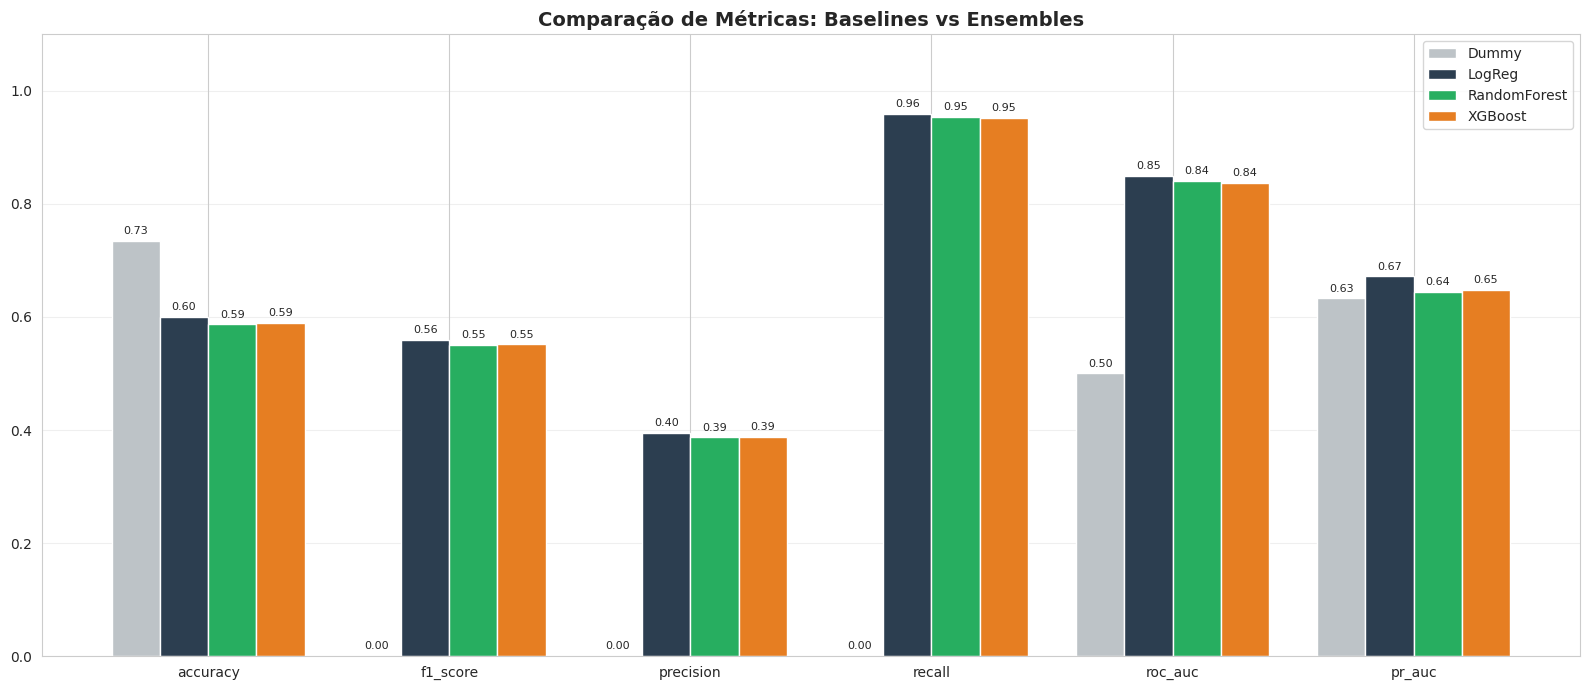

In [15]:
# =============================================================================
# COMPARAÇÃO VISUAL 1: PERFORMANCE ESTATÍSTICA
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(16, 7))

metric_names = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]

dummy_vals = [dummy_metrics[m] for m in metric_names]
lr_vals = [lr_metrics[m] for m in metric_names]
rf_vals = [rf_metrics[m] for m in metric_names]
xgb_vals = [xgb_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.20 

# Paleta
COLOR_DUMMY = "#BDC3C7"  # Cinza neutro (Baseline)
COLOR_LR    = "#2C3E50"  # Azul escuro/Petróleo (Linear)
COLOR_RF    = "#27AE60"  # Verde esmeralda (Ensemble - Bagging)
COLOR_XGB   = "#E67E22"  # Laranja (Ensemble - Boosting)

# Aplicando no seu código
ax1.bar(x - 1.5*width, dummy_vals, width, label="Dummy", color=COLOR_DUMMY)
ax1.bar(x - 0.5*width, lr_vals, width, label="LogReg", color=COLOR_LR)
ax1.bar(x + 0.5*width, rf_vals, width, label="RandomForest", color=COLOR_RF)
ax1.bar(x + 1.5*width, xgb_vals, width, label="XGBoost", color=COLOR_XGB)

ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, rotation=0, fontsize=10)
ax1.set_ylim(0, 1.1)
ax1.set_title("Comparação de Métricas: Baselines vs Ensembles", fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(axis="y", alpha=0.3)

# Adicionar rótulos nas barras
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.show()

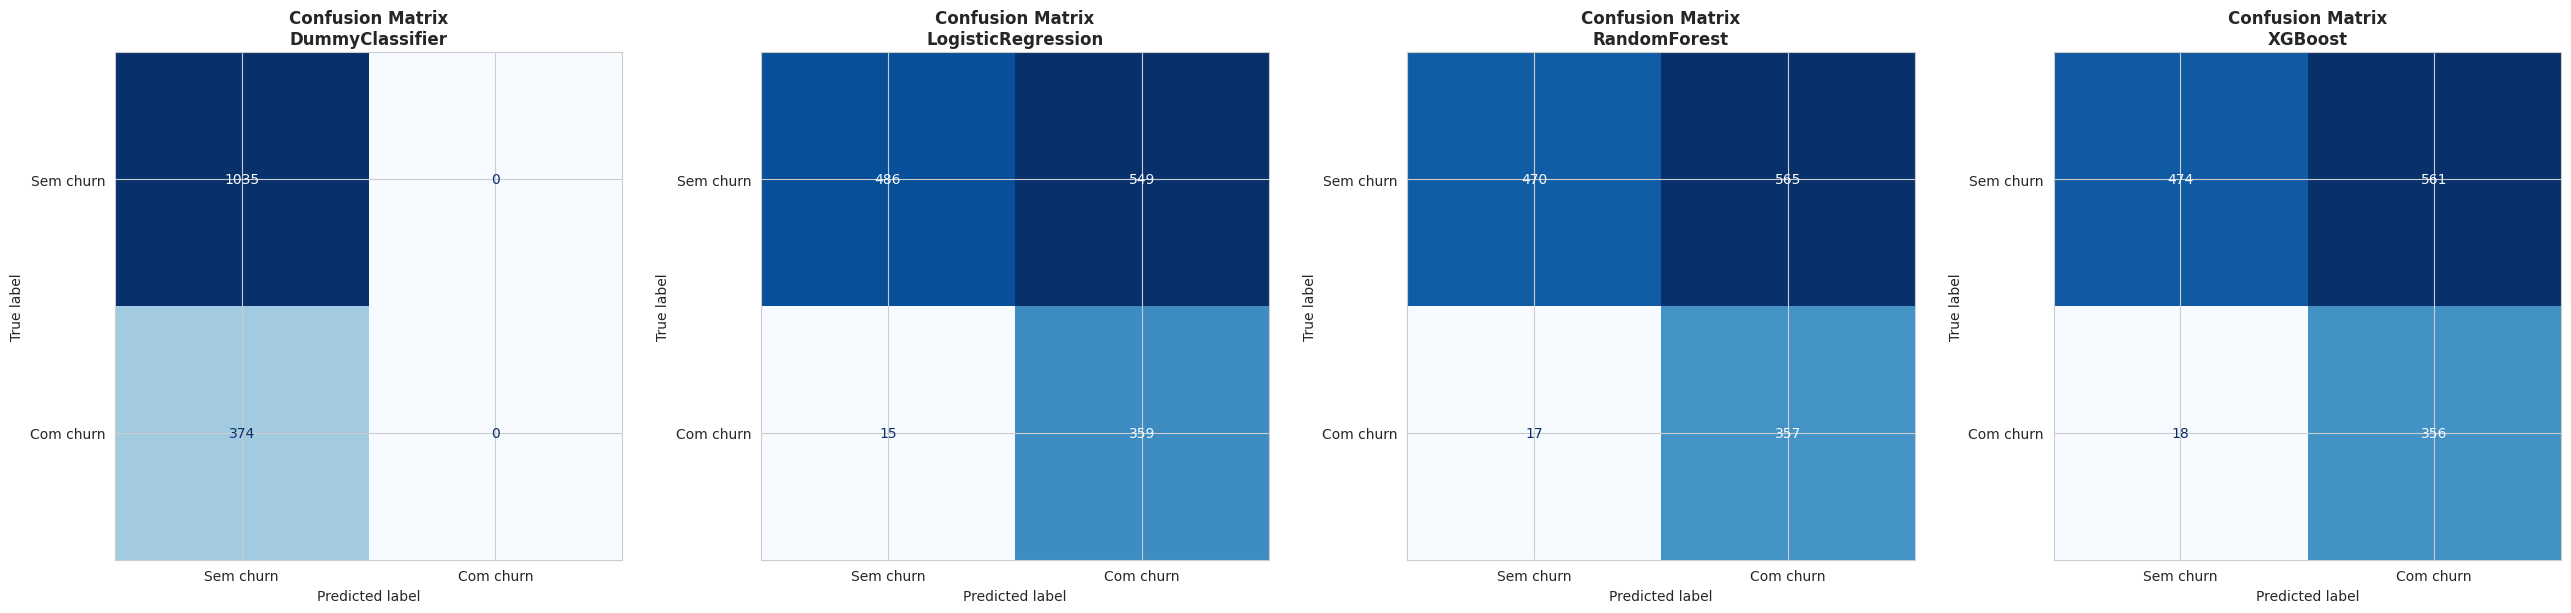

In [16]:
# =============================================================================
# COMPARAÇÃO VISUAL 2: IMPACTO NO NEGÓCIO (CONFUSION MATRICES)
# =============================================================================
fig2, axes2 = plt.subplots(1, 4, figsize=(26, 6))

models_cm = [
    (dummy_cm, "DummyClassifier"),
    (lr_cm, "LogisticRegression"),
    (rf_cm, "RandomForest"),
    (xgb_cm, "XGBoost")
]

for i, (cm, name) in enumerate(models_cm):
    ConfusionMatrixDisplay(cm, display_labels=["Sem churn", "Com churn"]).plot(
        ax=axes2[i], cmap="Blues", colorbar=False
    )
    axes2[i].set_title(f"Confusion Matrix\n{name}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
# --- Resumo final Consolidado ---
print("\n" + "="*80)
print(" RESUMO DOS EXPERIMENTOS (BASELINES, ENSEMBLES & BUSINESS IMPACT)")
print("="*80)

metricas_financeiras = ["custo_churn_evitado_BRL", "custo_falso_positivo_BRL", "custo_churn_perdido_BRL", "lucro_liquido_BRL"]

resumo = pd.DataFrame({
    "Métrica": metric_names + metricas_financeiras,
    "Dummy": dummy_vals + [dummy_metrics[m] for m in metricas_financeiras],
    "LogReg": lr_vals + [lr_metrics[m] for m in metricas_financeiras],
    "RandomForest": rf_vals + [rf_metrics[m] for m in metricas_financeiras],
    "XGBoost": xgb_vals + [xgb_metrics[m] for m in metricas_financeiras],
})

print(resumo.to_string(index=False))
print("="*80)


 RESUMO DOS EXPERIMENTOS (BASELINES, ENSEMBLES & BUSINESS IMPACT)
                 Métrica          Dummy        LogReg  RandomForest       XGBoost
                accuracy       0.734564      0.599716      0.586941      0.589070
                f1_score       0.000000      0.560062      0.550926      0.551510
               precision       0.000000      0.395374      0.387202      0.388222
                  recall       0.000000      0.959893      0.954545      0.951872
                 roc_auc       0.500000      0.849089      0.840492      0.837875
                  pr_auc       0.632718      0.671742      0.644796      0.647843
 custo_churn_evitado_BRL       0.000000 143600.000000 142800.000000 142400.000000
custo_falso_positivo_BRL       0.000000  54900.000000  56500.000000  56100.000000
 custo_churn_perdido_BRL  187000.000000   7500.000000   8500.000000   9000.000000
       lucro_liquido_BRL -187000.000000  81200.000000  77800.000000  77300.000000


# Arquitetura MLP

## Decisões de arquitetura, ativação e loss

A escolha do MLP é deliberadamente **parsimoniosa** para o tamanho do dataset (~5.6k amostras de treino, 28 features):

- **Arquitetura:** `28 → hidden → BatchNorm → Dropout → 1` (uma camada oculta). A capacidade é modulada via grid em `hidden_dims ∈ {8, 16, 32}`. **Por que apenas 1 camada oculta:** experimentamos uma variante com 2 camadas ocultas e a performance foi praticamente idêntica — nenhuma das arquiteturas testadas conseguiu superar a Logistic Regression em lucro líquido. Como a versão de 2 camadas não trouxe ganho mensurável e adicionaria parâmetros, complexidade de tuning e maior risco de overfitting nesse regime (~5.6k amostras de treino), mantivemos 1 camada oculta — princípio de parcimônia. `BatchNorm1d` estabiliza a escala dos ativadores e `Dropout` ataca overfitting.
- **Ativação:** `ReLU` na camada oculta. Não-saturante, gradiente bem-comportado e barata em CPU. Alternativas (LeakyReLU, GELU) foram descartadas por não trazer ganho documentado em datasets tabulares deste porte.
- **Loss:** `BCEWithLogitsLoss` (sigmoid + BCE numericamente estável) com `pos_weight = n_neg / n_pos ≈ 2.77`. É o equivalente PyTorch do `class_weight='balanced'` usado na Logistic Regression — mantém a comparação justa entre os modelos sem precisar de SMOTE/undersampling.
- **Otimizador:** `Adam` (varredo em `lr ∈ {1e-2, 1e-3}`), com `early stopping` (patience=20) sobre `val_loss` para evitar overfitting nas folds.

Essas decisões atendem o requisito da Etapa 2 ("definir arquitetura, função de ativação, loss function") e mantêm a parcimônia exigida quando comparamos contra LogReg.


In [18]:
# Grid Search com Nested Runs

param_grid = {
    "lr":          [1e-2, 1e-3],
    "dropout":     [0.0, 0.15, 0.3],
    "batch_size":  [32, 64, 128],
    "hidden_dims": [32, 16, 8]
}

# Valores fixos
PATIENCE     = 20
EPOCHS       = 100
OPTIMIZER    = "Adam"
ACTIVATION   = "ReLU"

# pos_weight: equivalente ao class_weight='balanced'
n_neg = (y_dev == 0).sum()
n_pos = (y_dev == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32)

# Gera todas as combinações
combinations = list(itertools.product(*param_grid.values()))
print(f"Total de combinações: {len(combinations)}")

Total de combinações: 54


In [19]:
class ChurnMLP(nn.Module):
    """MLP simplificada com 1 camada oculta, ReLU e BatchNorm."""

    def __init__(self, input_dim: int, hidden: int, dropout: float):
        super().__init__()
        # Camada de entrada -> Camada oculta
        self.fc1 = nn.Linear(input_dim, hidden)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(hidden)
        self.drop = nn.Dropout(dropout)
        
        # Camada oculta -> Saída (1 neurônio para o logit)
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.bn1(x)
        x = self.drop(x)
        x = self.fc2(x)
        return x.squeeze(-1)

In [20]:
def train_mlp(model, train_loader: DataLoader, val_loader: DataLoader,
              criterion, optimizer, patience: int = 10, epochs: int = 100):
    """Treina a MLP com early stopping e retorna o histórico de loss."""

    best_val_loss = float("inf")
    best_weights = None
    history = {"train_loss": [], "val_loss": []}
    stop_epoch = epochs

    for epoch in range(1, epochs + 1):

        # --- Treino ---
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()                               # Zera gradientes acumulados
            preds = model(X_batch)                              # Forward: calcula saída para todas as entradas
            loss = criterion(preds, y_batch.float().view(-1))   # Calcula o erro (loss) em relação ao esperado
            loss.backward()                                     # Backpropagation: gradiente dos pesos
            optimizer.step()                                    # Atualiza os pesos (descida do gradiente)
            train_loss += loss.item()                           # Acumula o valor do loss
        
        train_loss /= len(train_loader) # Média do loss por batch
    
        # --- Validação ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds = model(X_batch)
                loss = criterion(preds, y_batch.float().view(-1))
                val_loss += loss.item()
        val_loss /= len(val_loader)
    
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # --- Early Stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                stop_epoch = epoch
                break
    
    if best_weights:
        model.load_state_dict(best_weights)

    return history, best_val_loss, stop_epoch

In [21]:
def run_kfold_experiment(lr: float, dropout: float, batch_size: int, hidden_dims: int, X_dev, y_dev, skf, parent_run_id):
    """Executa 10-Fold CV para UMA combinação de hiperparâmetros."""

    fold_lucros = []
    all_fold_metrics = []
    list_thresholds = []
    stop_epochs = []
    all_train_losses = []
    all_val_losses = []

    # O loop do K-Fold garante o pareamento com os baselines
    for i, (train_idx, val_idx) in enumerate(skf.split(X_dev, y_dev)):

        # 1. Splits
        X_tr_f, X_val_f = X_dev.iloc[train_idx], X_dev.iloc[val_idx]
        y_tr_f, y_val_f = y_dev.iloc[train_idx], y_dev.iloc[val_idx]

        # 2. Scaling
        scaler = StandardScaler()
        X_tr_f_scaled = torch.tensor(scaler.fit_transform(X_tr_f), dtype=torch.float32)
        X_val_f_scaled = torch.tensor(scaler.transform(X_val_f), dtype=torch.float32)
        y_tr_f_tensor = torch.tensor(y_tr_f.values, dtype=torch.float32).view(-1, 1)
        y_val_f_tensor = torch.tensor(y_val_f.values, dtype=torch.float32).view(-1, 1)

        # 3. DataLoaders
        train_loader = DataLoader(TensorDataset(X_tr_f_scaled, y_tr_f_tensor), batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(TensorDataset(X_val_f_scaled, y_val_f_tensor), batch_size=batch_size, shuffle=False)

        # 4. Init Model
        model = ChurnMLP(X_dev.shape[1], hidden_dims, dropout)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # 5. Train (Early Stopping)
        history, best_val, stop_ep = train_mlp(model, train_loader, val_loader, criterion, optimizer, patience=PATIENCE, epochs=EPOCHS)

        # 6. Eval na dobra de validação
        model.eval()
        with torch.no_grad():
            y_proba = torch.sigmoid(model(X_val_f_scaled)).numpy().flatten()
        
        t_opt = find_optimal_threshold(y_val_f, y_proba)
        y_pred = (y_proba >= t_opt).astype(int)
        
        metrics_f = calculate_metrics(y_val_f, y_proba, t_opt)
        fold_lucros.append(metrics_f['lucro_liquido_BRL'])
        stop_epochs.append(stop_ep)
        list_thresholds.append(t_opt)
        all_fold_metrics.append(metrics_f)
        all_train_losses.append(history["train_loss"])
        all_val_losses.append(history["val_loss"])

        print(f"▸ Fold {i+1:02d}/10: Stop @{stop_ep:02d} | "
      f"Train: {history['train_loss'][-1]:.4f} | "
      f"Val: {history['val_loss'][-1]:.4f} | "
      f"⭐ Best Val: {best_val:.4f}")

    # --- Resumo da Combinação ---
    metrics = {k: np.mean([m[k] for m in all_fold_metrics]) for k in all_fold_metrics[0].keys()}
    metrics["lucro_std"] = np.std(fold_lucros)
    metrics["best_epoch_median"] = max(1, int(np.median(stop_epochs) - PATIENCE))
    metrics["best_threshold_median"] = np.median(list_thresholds)

    print(f"{'-'*85}")
    print(f"✨ RESULTADO FINAL: Lucro Médio R$ {metrics['lucro_liquido_BRL']:,.2f} | Std: R$ {metrics['lucro_std']:,.2f}")
    print(f"{'-'*85}\n")

    # Log no MLflow como Nested Run
    run_name = f"MLP_lr={lr}_dropout={dropout}_batch={batch_size}_hidden_dims={hidden_dims}"
    with mlflow.start_run(run_name=run_name, nested=True, parent_run_id=parent_run_id):

        # Log parâmetros
        mlflow.log_params({
            "lr":           lr,
            "dropout":      dropout,
            "batch_size":   batch_size,
            "hidden_dims":  hidden_dims,
            "patience":     PATIENCE,
            "epochs_max":   EPOCHS,
            "optimizer":    OPTIMIZER,
            "activation":   ACTIVATION,
            "pos_weight":   round(pos_weight.item(), 2),
        })

        # Log métricas
        mlflow.log_metrics(metrics)
        mlflow.log_metrics({
            "kfold_lucro_medio": np.mean(fold_lucros),
            "kfold_lucro_std":   np.std(fold_lucros),
            "kfold_lucro_min":   np.min(fold_lucros),
            "kfold_lucro_max":   np.max(fold_lucros)
        })

        # Logamos o vetor de lucros como artefato ou steps para o Friedman
        for i, l in enumerate(fold_lucros):
            mlflow.log_metric("lucro_fold", l, step=i)
        
        for i, ep in enumerate(stop_epochs):
            mlflow.log_metric("stop_epoch", ep, step=i)
        
        mlflow.set_tag("model_type", "ChurnMLP_tuning")
        mlflow.set_tag("etapa", "2")

        min_epochs = min(len(h) for h in all_train_losses)
    
        avg_train_loss = np.mean([h[:min_epochs] for h in all_train_losses], axis=0)
        avg_val_loss   = np.mean([h[:min_epochs] for h in all_val_losses], axis=0)

        # No log do MLflow
        for i, (tl, vl) in enumerate(zip(avg_train_loss, avg_val_loss)):
            mlflow.log_metric("train_loss_avg", tl, step=i)
            mlflow.log_metric("val_loss_avg",   vl, step=i)

        # 1. Converte para tipos nativos do Python
        lucros_nativos = [float(x) for x in fold_lucros]

        # 2. Cria o arquivo temporário
        with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as tmp:
            json.dump(lucros_nativos, tmp)
            temp_path = tmp.name

        # 3. Faz o log usando o caminho
        mlflow.log_artifact(temp_path, "vetor_lucros.json")

        # Remove o arquivo temporário após o log
        import os
        os.unlink(temp_path)

    return metrics, fold_lucros, run_name

In [22]:
resultados_mlp = []

with mlflow.start_run(run_name="MLP_GridSearch_KFold") as parent_run:

    # Log DataSet
    mlflow.log_input(mlflow_train_dataset, context="training")
    mlflow.log_input(mlflow_test_dataset, context="testing")

    # Log de parâmetros e métricas
    mlflow.log_params(dataset_params)

    for i, (lr, dropout, batch_size, hidden_dims) in enumerate(combinations):

        config_desc = f" [{i+1}/{len(combinations)}] CONFIG: {hidden_dims} units | LR: {lr} | DRP: {dropout} | BS: {batch_size} "
        print(f"\n{'='*80}\n{config_desc}\n{'='*80}")
                
        # Chama a função que faz os 10 folds para esta config
        metrics, vetor_l, name = run_kfold_experiment(
            lr, dropout, batch_size, hidden_dims, X_dev, y_dev, skf, parent_run.info.run_id
        )
        
        resultados_mlp.append({
            "metrics": metrics,
            "vetor_lucros": vetor_l,
            "best_epoch_median": metrics["best_epoch_median"],
            "best_threshold_median": metrics["best_threshold_median"],
            "params": { "lr": lr, "dropout": dropout, "batch_size": batch_size, "hidden_dims": hidden_dims }
        })


 [1/54] CONFIG: 32 units | LR: 0.01 | DRP: 0.0 | BS: 32 
▸ Fold 01/10: Stop @21 | Train: 0.6692 | Val: 0.8085 | ⭐ Best Val: 0.7549
▸ Fold 02/10: Stop @24 | Train: 0.6735 | Val: 0.7181 | ⭐ Best Val: 0.6866
▸ Fold 03/10: Stop @27 | Train: 0.6609 | Val: 0.7775 | ⭐ Best Val: 0.7263
▸ Fold 04/10: Stop @34 | Train: 0.6687 | Val: 0.7735 | ⭐ Best Val: 0.7344
▸ Fold 05/10: Stop @23 | Train: 0.6655 | Val: 0.7413 | ⭐ Best Val: 0.7170
▸ Fold 06/10: Stop @40 | Train: 0.6584 | Val: 0.7573 | ⭐ Best Val: 0.7067
▸ Fold 07/10: Stop @24 | Train: 0.6700 | Val: 0.7061 | ⭐ Best Val: 0.6821
▸ Fold 08/10: Stop @27 | Train: 0.6596 | Val: 0.7181 | ⭐ Best Val: 0.6811
▸ Fold 09/10: Stop @21 | Train: 0.6741 | Val: 0.7431 | ⭐ Best Val: 0.7007
▸ Fold 10/10: Stop @24 | Train: 0.6610 | Val: 0.7023 | ⭐ Best Val: 0.6575
-------------------------------------------------------------------------------------
✨ RESULTADO FINAL: Lucro Médio R$ 31,680.00 | Std: R$ 2,274.55
-----------------------------------------------------

In [29]:
# 1. Top 3 MLPs com base no lucro médio do K-Fold
top_n = 3
top_mlps = sorted(resultados_mlp, key=lambda x: np.mean(x["vetor_lucros"]), reverse=True)[:top_n]

# 2. Dicionário de comparação
dados_para_df = {
    'Dummy': lucros_dummy,
    'LogReg': lucros_lr,
    'RandomForest': lucros_rf,
    'XGBoost': lucros_xgb
}

# Adicionar as top MLPs dinamicamente
for i, res in enumerate(top_mlps):
    
    h_dims = res['params']['hidden_dims']
    lr     = res['params']['lr']
    drp    = res['params']['dropout']
    batch  = res['params']['batch_size']

    nome_col = f"MLP_{h_dims}_lr{lr}_drp{drp}_b{batch}"
    dados_para_df[nome_col] = res['vetor_lucros']


df_final = pd.DataFrame(dados_para_df)

print("=== Tabela de Lucros por Fold (Modelos vs LogReg) ===")
print(df_final.mean().sort_values(ascending=False)) # Médias ordenadas
print("-" * 50)

# 3. Teste de Friedman com todos os modelos
stat, p_friedman = friedmanchisquare(*(df_final[col] for col in df_final.columns))

print(f"Teste de Friedman Global:")
print(f"Estatística: {stat:.4f}, p-valor: {p_friedman:.4e}")

# 4. Post-hoc Nemenyi para ver QUEM ganha de QUEM
if p_friedman < 0.05:
    print("\n✅ Diferença detectada! Rodando Nemenyi...")
    # O posthoc_nemenyi_friedman espera os dados onde cada coluna é um modelo
    p_values = sp.posthoc_nemenyi_friedman(df_final.values)
    
    # Ajustar nomes para visualização
    p_values.columns = df_final.columns
    p_values.index = df_final.columns
    
    print("\nMatriz de p-valores (Nemenyi):")
    # Vamos focar na coluna da LogReg para ver quem ganha dela
    print(p_values[['LogReg']].sort_values(by='LogReg'))
else:
    print("\n❌ Todos os modelos são estatisticamente equivalentes à LogReg.")

=== Tabela de Lucros por Fold (Modelos vs LogReg) ===
MLP_32_lr0.001_drp0.0_b128    33340.0
MLP_8_lr0.001_drp0.3_b128     33200.0
MLP_8_lr0.01_drp0.3_b128      33130.0
LogReg                        33120.0
XGBoost                       32360.0
RandomForest                  32340.0
Dummy                        -74750.0
dtype: float64
--------------------------------------------------
Teste de Friedman Global:
Estatística: 30.8280, p-valor: 2.7340e-05

✅ Diferença detectada! Rodando Nemenyi...

Matriz de p-valores (Nemenyi):
                              LogReg
Dummy                       0.000687
RandomForest                0.645473
XGBoost                     0.803522
MLP_8_lr0.01_drp0.3_b128    0.982115
MLP_8_lr0.001_drp0.3_b128   0.998617
MLP_32_lr0.001_drp0.0_b128  0.999975
LogReg                      1.000000


=== Resumo Estatístico (Ordenado por Média) ===


,mean,std,min,max,coef_variacao
MLP_32_lr0.001_drp0.0_b128,33340.0,1860.226987,30700.0,35900.0,5.579565
MLP_8_lr0.001_drp0.3_b128,33200.0,1843.306208,30100.0,35400.0,5.552127
MLP_8_lr0.01_drp0.3_b128,33130.0,1776.419620,30000.0,35200.0,5.361967
MLP_16_lr0.001_drp0.3_b64,33130.0,1711.432149,29900.0,35500.0,5.165808
MLP_8_lr0.01_drp0.15_b64,33050.0,1569.323988,30700.0,35200.0,4.748333
MLP_8_lr0.01_drp0.15_b128,32980.0,1788.108871,29200.0,35100.0,5.421798
MLP_8_lr0.001_drp0.0_b32,32970.0,2422.143220,29400.0,35900.0,7.346507
MLP_32_lr0.001_drp0.3_b128,32940.0,2106.708860,29200.0,35500.0,6.395595
MLP_8_lr0.01_drp0.15_b32,32830.0,1751.856158,31000.0,36000.0,5.336144
MLP_8_lr0.001_drp0.15_b32,32820.0,1826.836975,29700.0,35700.0,5.566231


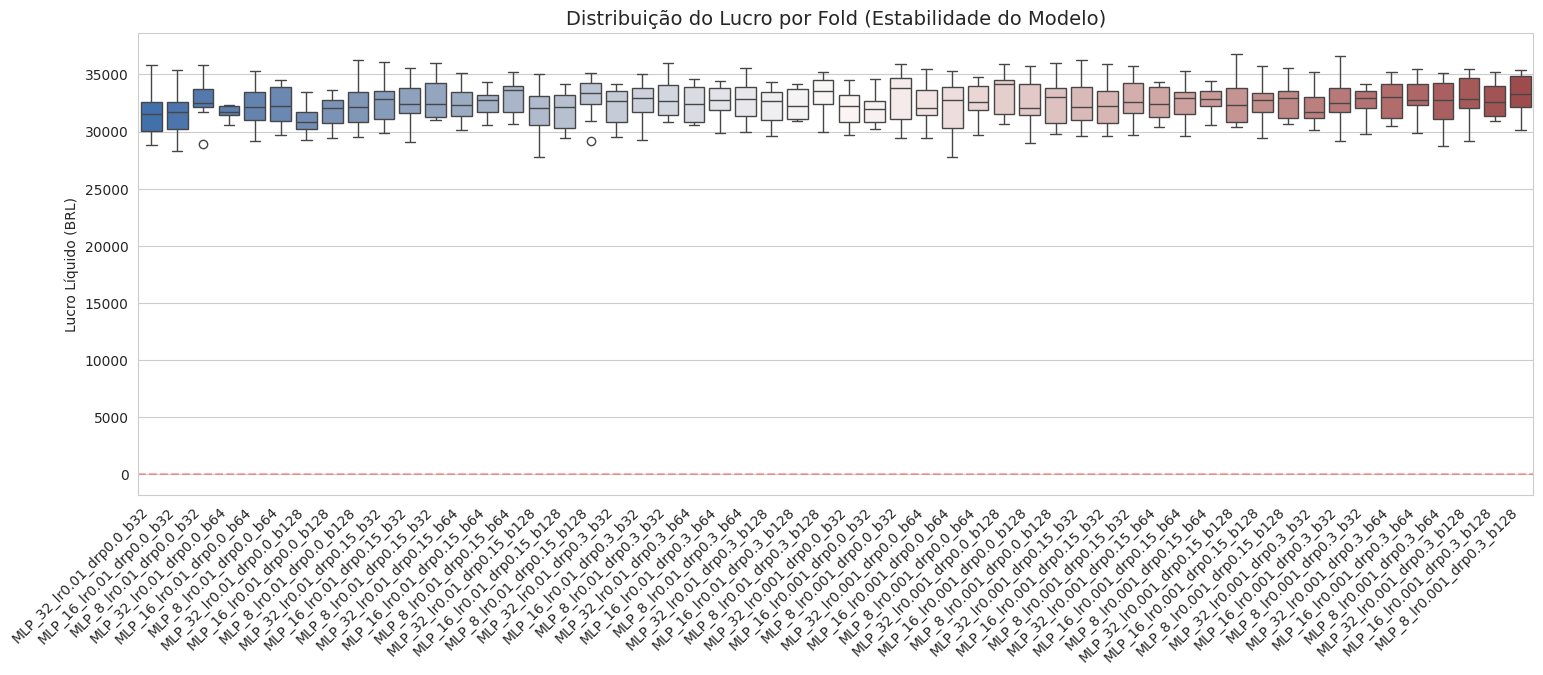

In [30]:
# Criando o DataFrame de comparação
df_comparacao = pd.DataFrame()

for res in resultados_mlp:
    p = res['params']
    nome_col = f"MLP_{p['hidden_dims']}_lr{p['lr']}_drp{p['dropout']}_b{p['batch_size']}"
    
    # Preenchemos as 10 linhas (os folds)
    df_comparacao[nome_col] = res['vetor_lucros']

# Calculando as estatísticas
estatisticas = df_comparacao.agg(['mean', 'std', 'min', 'max']).T
estatisticas['coef_variacao'] = (estatisticas['std'] / estatisticas['mean']) * 100
estatisticas = estatisticas.sort_values(by='mean', ascending=False)

print("=== Resumo Estatístico (Ordenado por Média) ===")
display(estatisticas)

# --- Visualização de Estabilidade ---
plt.figure(figsize=(18, 6))
sns.boxplot(data=df_comparacao, palette="vlag")
plt.xticks(rotation=45, ha='right')
plt.title("Distribuição do Lucro por Fold (Estabilidade do Modelo)")
plt.ylabel("Lucro Líquido (BRL)")
plt.axhline(y=0, color='red', linestyle='--', alpha=0.3) # Linha do prejuízo
plt.show()

In [31]:
# 1. Filtra as runs do experimento atual com base nos parâmetros da sua "campeã de estabilidade"
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# Buscamos apenas a run que bate com os parâmetros específicos
query = "params.hidden_dims = '8' and params.lr = '0.01' and params.dropout = '0.15' and params.batch_size = '128'"
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], filter_string=query)

if not runs.empty:
    # Pegamos o ID da primeira run encontrada (deveria ser única para essa config)
    run_id_estavel = runs.iloc[0].run_id
    print(f"🎯 Encontrado! O Run ID é: {run_id_estavel}")
else:
    print("❌ Não encontrei nenhuma run com esses parâmetros exatos.")

🎯 Encontrado! O Run ID é: 40c7b775727f4e8f9f523f8824147cb3


In [32]:
client = mlflow.tracking.MlflowClient()
data = client.get_run(run_id_estavel).data

In [33]:
# Parâmetros da Run com melhor estabilidade
lr         = 0.01
hidden     = 8
batch_size = 128
dropout    = 0.15
epochs     = 15
t_opt      = 0.203030303030303

# --- Treino Final com Dados Completos ---
scaler = StandardScaler()
X_dev_final = torch.tensor(scaler.fit_transform(X_dev), dtype=torch.float32)
X_test_final = torch.tensor(scaler.transform(X_test), dtype=torch.float32)
y_dev_final = torch.tensor(y_dev.values, dtype=torch.float32).view(-1, 1)
y_test_final = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

dataset_final = TensorDataset(X_dev_final, y_dev_final)
loader_final = DataLoader(dataset_final, batch_size=batch_size, shuffle=True)

# Instancia o modelo com a config campeã
model_final = ChurnMLP(input_dim=X_dev.shape[1], hidden=hidden, dropout=dropout)
optimizer = optim.Adam(model_final.parameters(), lr=lr)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Treina pelo número médio de épocas
for epoch in range(epochs):
    model_final.train()
    for xb, yb in loader_final:
        optimizer.zero_grad()
        loss = criterion(model_final(xb), yb.float().view(-1))
        loss.backward()
        optimizer.step()

model_final.eval()
with torch.no_grad():
    y_proba = torch.sigmoid(model_final(X_test_final)).numpy().flatten()

y_pred = (y_proba >= t_opt).astype(int)
        
metrics_f = calculate_metrics(y_test_final, y_proba, t_opt)

# --- Registro no MLflow na Run Pai ---
with mlflow.start_run(run_id=parent_run.info.run_id):
    mlflow.set_tag("etapa", "2")

    scaler_filename = "scaler.joblib"
    joblib.dump(scaler, scaler_filename)
    # Registra o arquivo na pasta 'model_components' dentro da run
    mlflow.log_artifact(scaler_filename, artifact_path="model_components")
    
    # Limpa o arquivo local temporário
    if os.path.exists(scaler_filename):
        os.remove(scaler_filename)

    # Log parâmetros
    mlflow.log_params({
        "lr":           lr,
        "dropout":      dropout,
        "batch_size":   batch_size,
        "hidden_dims":  hidden,
        "patience":     PATIENCE,
        "epochs_max":   epochs,
        "optimizer":    OPTIMIZER,
        "activation":   ACTIVATION,
        "pos_weight":   round(pos_weight.item(), 2),
    })

    mlflow.log_param("final_training_data_size", len(X_dev))
    mlflow.log_param("fixed_epochs", epochs)
    mlflow.log_metrics(metrics_f)
    
    # Loga o modelo final e já o registra no Registry
    mlflow.pytorch.log_model(
        pytorch_model=model_final,
        artifact_path="final_model_prod",
        registered_model_name="Churn_MLP_Final_Production"
    )

    print("🚀 Modelo Final treinado com 100% dos dados e registrado na Run Pai!")

Registered model 'Churn_MLP_Final_Production' already exists. Creating a new version of this model...
Created version '11' of model 'Churn_MLP_Final_Production'.


🚀 Modelo Final treinado com 100% dos dados e registrado na Run Pai!
🏃 View run MLP_GridSearch_KFold at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13/runs/c37c092298f1444cb566eab9beb84f18
🧪 View experiment at: https://dagshub.com/JosueJNLui/fiap-mlet-challenge-fase-1.mlflow/#/experiments/13


## Trade-off de custo: Falso Positivo vs Falso Negativo

Requisito explícito da Etapa 2. Visualizamos como o **lucro líquido** reage ao threshold e como o **custo se distribui entre FP e FN** sobre o hold-out, usando o MLP campeão treinado acima. O potencial threshold a ser servido em produção (`0.20303`) foi selecionado em validação cruzada — o gráfico abaixo confirma que ele cai na região de máximo lucro.


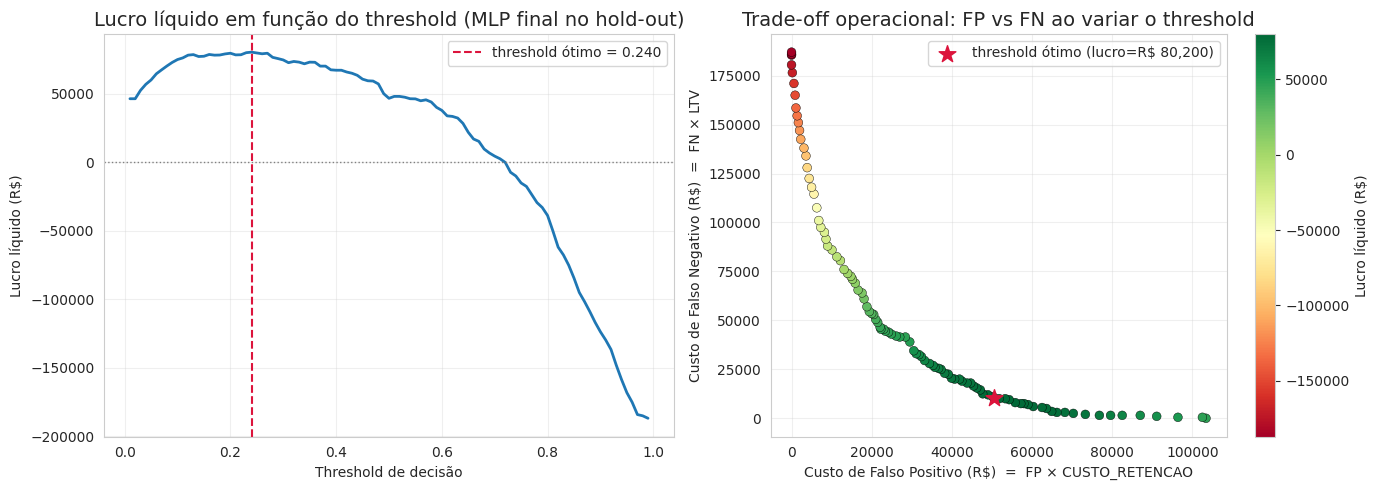

Potencial threshold a ser servido em produção: 0.20303 (selecionado em validação cruzada)
Threshold ótimo neste hold-out: 0.2400 (lucro R$ 80,200)
Como FN custa 5x o FP (LTV R$500 vs custo retenção R$100), a curva é assimétrica e o ótimo cai em thresholds baixos — favorecendo recall.


In [36]:
# --- Análise de trade-off: Falso Positivo vs Falso Negativo (Etapa 2) ---
# Reaproveita y_proba e y_test_final do treino final acima para visualizar como
# o lucro líquido reage ao threshold e como o custo se distribui entre FP e FN.
import numpy as _np
import matplotlib.pyplot as _plt
from sklearn.metrics import confusion_matrix as _confusion_matrix

_y_true_arr = _np.asarray(y_test_final).ravel().astype(int)
_thresholds = _np.linspace(0.01, 0.99, 99)
_lucros, _custos_fp, _custos_fn = [], [], []
for _t in _thresholds:
    _y_hat = (y_proba >= _t).astype(int)
    _tn, _fp, _fn, _tp = _confusion_matrix(_y_true_arr, _y_hat).ravel()
    _custos_fp.append(_fp * CUSTO_RETENCAO)
    _custos_fn.append(_fn * VALOR_CLIENTE_LTV)
    _lucros.append(_tp * (VALOR_CLIENTE_LTV - CUSTO_RETENCAO) - _fp * CUSTO_RETENCAO - _fn * VALOR_CLIENTE_LTV)

_idx_opt = int(_np.argmax(_lucros))
_t_opt = _thresholds[_idx_opt]

fig, axes = _plt.subplots(1, 2, figsize=(14, 5))

# (a) Lucro líquido vs threshold
axes[0].plot(_thresholds, _lucros, color="#1f77b4", lw=2)
axes[0].axvline(_t_opt, color="crimson", ls="--", lw=1.5, label=f"threshold ótimo = {_t_opt:.3f}")
axes[0].axhline(0, color="grey", ls=":", lw=1)
axes[0].set_xlabel("Threshold de decisão")
axes[0].set_ylabel("Lucro líquido (R$)")
axes[0].set_title("Lucro líquido em função do threshold (MLP final no hold-out)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# (b) Trade-off FP vs FN, colorido por lucro
sc = axes[1].scatter(_custos_fp, _custos_fn, c=_lucros, cmap="RdYlGn", s=40, edgecolor="black", lw=0.3)
axes[1].scatter(_custos_fp[_idx_opt], _custos_fn[_idx_opt], color="crimson", s=160, marker="*", label=f"threshold ótimo (lucro=R$ {_lucros[_idx_opt]:,.0f})")
axes[1].set_xlabel("Custo de Falso Positivo (R$)  =  FP × CUSTO_RETENCAO")
axes[1].set_ylabel("Custo de Falso Negativo (R$)  =  FN × LTV")
axes[1].set_title("Trade-off operacional: FP vs FN ao variar o threshold")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)
fig.colorbar(sc, ax=axes[1], label="Lucro líquido (R$)")

_plt.tight_layout()
_plt.show()

print(f"Potencial threshold a ser servido em produção: 0.20303 (selecionado em validação cruzada)")
print(f"Threshold ótimo neste hold-out: {_t_opt:.4f} (lucro R$ {_lucros[_idx_opt]:,.0f})")
print("Como FN custa 5x o FP (LTV R$500 vs custo retenção R$100), a curva é assimétrica e o ótimo cai em thresholds baixos — favorecendo recall.")
